In [2]:
# Neural Network Audio Saturation - Complete Workflow
# 
# This notebook trains a neural network to learn a saturation function (tanh)
# and applies it to real audio. All processing uses proper audio range: -1 to +1

# ## 1. Generate Audio Data (for Training)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import librosa
from math import tanh
import soundfile as sf

In [3]:
clean_training_sample = './Cardboard Box Beat.wav'

clean_data, audio_sr = librosa.load(clean_training_sample, sr=None, mono=False)

print("Clean Data")
display(Audio(data=clean_data, rate=audio_sr))

Clean Data


In [4]:

def process_audio(audio, drive=1.0):
    # Apply a simple saturation function (tanh) to the audio
    return np.tanh(drive * audio) / drive

def one_pole(audio, coefficient):
    out = np.copy(audio)
    for i in range(1, len(audio)):
        out[i] = audio[i] + coefficient * out[i - 1]
    return out

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sin_dist(signal, drive): 
    out = np.sin(signal * drive) / drive
    return out

def noise(audio, drive=0.1): 
    noise = np.random.rand(*audio.shape) * 2.0 - 1.0
    filtered_noise = one_pole(one_pole(noise, 0.2), 0.2);
    f = audio * 0.5
    out = audio + (filtered_noise * drive * audio * f)
    return out

In [5]:
import numpy as np
from math import tanh
import random

class DelayWithFeedback:
    def __init__(self, delay_ms, feedback=0.5, sample_rate=44100, drive=1.0):
        self.sample_rate = sample_rate
        self.feedback = np.clip(feedback, 0, 0.99)
        self.drive = drive
        self.delay_samples = int((delay_ms / 1000.0) * sample_rate)
        self.buffers = []
        self.write_positions = []
        self.lp_states = []  # one-pole filter state per channel
    
    def _ensure_channels(self, num_channels):
        while len(self.buffers) < num_channels:
            self.buffers.append(np.zeros(self.delay_samples))
            self.write_positions.append(0)
            self.lp_states.append(0.0)

    def _process_sample(self, sample, ch):
        sample = float(sample)
        pos = self.write_positions[ch]
        delayed = self.buffers[ch][pos]

        # Saturate the feedback signal
        d2 = 3.0
        sat = np.sin(d2 * tanh(self.drive * delayed) / max(self.drive, 1e-7)) / d2 

        # Add filtered noise modulated by signal level
        n = (random.random() * 2.0 - 1.0) * 0.5 * abs(sat)
        self.lp_states[ch] = 0.8 * self.lp_states[ch] + 0.2 * n
        noisy = sat + self.lp_states[ch]

        self.buffers[ch][pos] = sample + (noisy * self.feedback)
        self.write_positions[ch] = (pos + 1) % self.delay_samples
        return delayed
    
    def process_block(self, samples):
        samples = np.asarray(samples, dtype=np.float32)
        
        if samples.ndim == 2:
            num_channels = samples.shape[0] if samples.shape[0] < samples.shape[1] else samples.shape[1]
            ch_axis = 0 if samples.shape[0] < samples.shape[1] else 1
            self._ensure_channels(num_channels)
            output = np.zeros_like(samples)
            for ch in range(num_channels):
                if ch_axis == 0:
                    for i in range(samples.shape[1]):
                        output[ch, i] = self._process_sample(samples[ch, i], ch)
                else:
                    for i in range(samples.shape[0]):
                        output[i, ch] = self._process_sample(samples[i, ch], ch)
            return output
        else:
            self._ensure_channels(1)
            output = np.zeros_like(samples)
            for i in range(len(samples)):
                output[i] = self._process_sample(samples[i], 0)
            return output

In [6]:
display(Audio(data=clean_data, rate=audio_sr))


delay = DelayWithFeedback(100, 0.8, audio_sr)
dirt = noise(clean_data, 0.92) 
sined = sin_dist(dirt, 4.5)
deld = delay.process_block(clean_data)
display(Audio(data=dirt, rate=audio_sr))
display(Audio(data=sined, rate=audio_sr))
display(Audio(data=deld, rate=audio_sr))

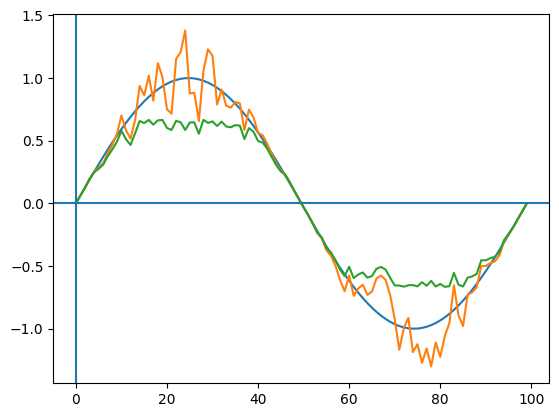

In [7]:
xx = np.linspace(0,1, 100)
sig = np.sin(np.pi * 2.0 * xx)
d = noise(sig, 0.61)
s = sin_dist(d, 1.5)
plt.plot(sig)
plt.plot(d)
plt.plot(s)
plt.axhline(y=0)
plt.axvline(x=0)

In [8]:
is_stereo = False;
saturated_audio = [];
drive = 4.0;

if len(clean_data.shape) == 2:
    is_stereo = True
    saturated_audio = np.stack([
        process_audio(ch, drive) for ch in clean_data
    ])
    print(f"  Processed stereo audio: {clean_data.shape[1]} samples at {audio_sr}Hz")
else:
    is_stereo = False
    saturated_audio = process_audio(clean_data, drive)
    print(f"  Processed mono audio: {len(clean_data)} samples at {audio_sr}Hz")

print("Clean Data")
display(Audio(data=clean_data, rate=audio_sr))

print("Saturated Data")
display(Audio(data=saturated_audio, rate=audio_sr))

  Processed stereo audio: 393216 samples at 96000Hz
Clean Data


Saturated Data


In [9]:
import random

class PlasmaDistortion:
    """
    Emulates plasma/xenon tube distortion characteristics:
    - Hard voltage threshold gate (tube only conducts above threshold)
    - Sputtering crackle zone near threshold (unstable ionization)
    - Harsh waveshaping + rectified harmonic blend
    - Instant silence below threshold
    """
    def __init__(self, voltage=5.0, threshold=0.02, sputter_width=0.04, sample_rate=44100):
        self.voltage = voltage            # drive intensity
        self.threshold = threshold        # gate threshold (below = silence)
        self.sputter_width = sputter_width  # width of crackling zone above threshold
        self.sr = sample_rate
        self.env = 0.0                    # envelope follower
        self.crackle_lp = 0.0            # filtered crackle state
        
    def process_sample(self, x):
        # --- Envelope follower (fast attack, slow release for sputtery tail) ---
        ax = abs(x)
        if ax > self.env:
            self.env += (ax - self.env) * 0.8      # fast attack ~0.02ms
        else:
            self.env *= 0.9997                       # slow release ~150ms at 44.1k

        gate_lo = self.threshold
        gate_hi = gate_lo + self.sputter_width

        # --- Below threshold: dead silence (plasma extinguished) ---
        if self.env < gate_lo:
            self.crackle_lp = 0.0
            return 0.0

        # --- Sputter zone: random firing near threshold ---
        in_sputter = self.env < gate_hi
        if in_sputter:
            fire_prob = (self.env - gate_lo) / self.sputter_width
            if random.random() > fire_prob:
                # Misfired — emit random crackle pop or silence
                if random.random() < 0.15:
                    pop = random.gauss(0, 0.2) * fire_prob
                    self.crackle_lp = 0.6 * self.crackle_lp + 0.4 * pop
                    return self.crackle_lp
                return 0.0

        # --- Plasma discharge waveshaping ---
        driven = x * self.voltage
        
        # Harsh clipping (steep tanh approximates the near-binary discharge)
        shaped = np.tanh(driven * 3.0)
        
        # Full-wave rectifier blend (even harmonics from antenna pickup)
        rect = abs(shaped) * np.sign(x)
        out = shaped * 0.7 + rect * 0.3
        
        # Add subtle crackle texture (electrical noise from discharge)
        proximity = max(0.0, 1.0 - (self.env - gate_lo) / (self.sputter_width * 4))
        noise = random.gauss(0, 0.03) * proximity
        self.crackle_lp = 0.85 * self.crackle_lp + 0.15 * noise
        out += self.crackle_lp
        
        # Gain compensation
        out /= max(self.voltage * 0.25, 1.0)
        
        return out
    
    def process_block(self, audio):
        """Process a numpy array (1D or 2D channels-first)."""
        audio = np.asarray(audio, dtype=np.float64)
        if audio.ndim == 2:
            output = np.zeros_like(audio)
            for ch in range(audio.shape[0]):
                # Reset envelope per channel? No — share for stereo coherence
                saved_env = self.env
                saved_lp = self.crackle_lp
                if ch > 0:
                    self.env = saved_env
                    self.crackle_lp = saved_lp
                for i in range(audio.shape[1]):
                    output[ch, i] = self.process_sample(audio[ch, i])
            return output
        else:
            output = np.zeros_like(audio)
            for i in range(len(audio)):
                output[i] = self.process_sample(audio[i])
            return output

Clean


Plasma


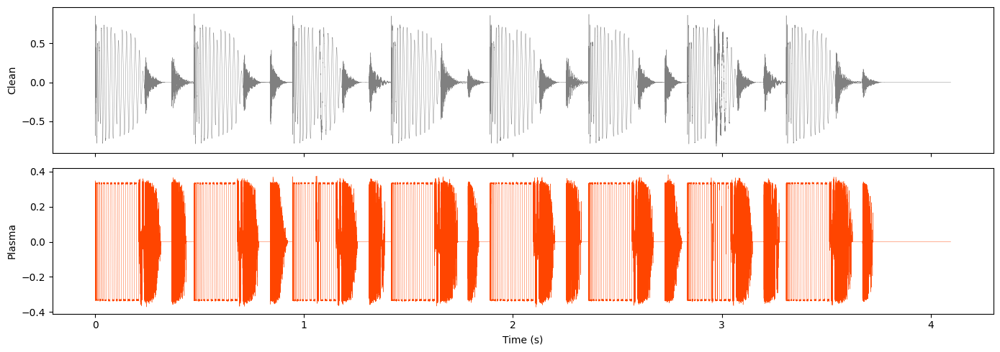

In [10]:
# --- Plasma Distortion Demo ---
plasma = PlasmaDistortion(voltage=12.0, threshold=0.05, sputter_width=0.4, sample_rate=audio_sr)
plasma_out = plasma.process_block(clean_data)

print("Clean")
display(Audio(data=clean_data, rate=audio_sr))
print("Plasma")
display(Audio(data=plasma_out, rate=audio_sr))

# Waveform comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t = np.arange(clean_data.shape[-1]) / audio_sr
ch = clean_data[0] if clean_data.ndim == 2 else clean_data
ch_out = plasma_out[0] if plasma_out.ndim == 2 else plasma_out
axes[0].plot(t, ch, linewidth=0.3, color='gray')
axes[0].set_ylabel('Clean')
axes[1].plot(t, ch_out, linewidth=0.3, color='orangered')
axes[1].set_ylabel('Plasma')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()